In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import json

# import all json files
with open("cross_val_results/evaluation_metrics_bert_ner.json", "r") as f:
    bert_metrics = json.load(f)

with open("cross_val_results/evaluation_metrics_dictionary_ner.json", "r") as f:
    dictionary_metrics = json.load(f)

with open("cross_val_results/evaluation_metrics_gen_llm_ner.json", "r") as f:
    gpt_results = json.load(f)

# combine all models
all_metrics = {**bert_metrics, **dictionary_metrics, **gpt_results}

# rename cross-span to cross_span
for model in all_metrics:
    if "cross-span" in all_metrics[model]:
        all_metrics[model]["cross_span"] = all_metrics[model].pop("cross-span")

# reorder the dictionaries
bert_metrics = dict(
    (k, bert_metrics[k]) for k in [
        'roberta-base',
        'microsoft/deberta-v3-base',
        'bert-base-cased',
        'distilbert-base-cased'
    ]
)    

all_metrics = dict(
    (k, all_metrics[k]) for k in [
        'roberta-base',
        'microsoft/deberta-v3-base',
        'bert-base-cased',
        'distilbert-base-cased',
        'dictionary',
        'gpt-5-nano',
        'gpt-4o-mini'
    ]
)

# Comparison Across BERT Models

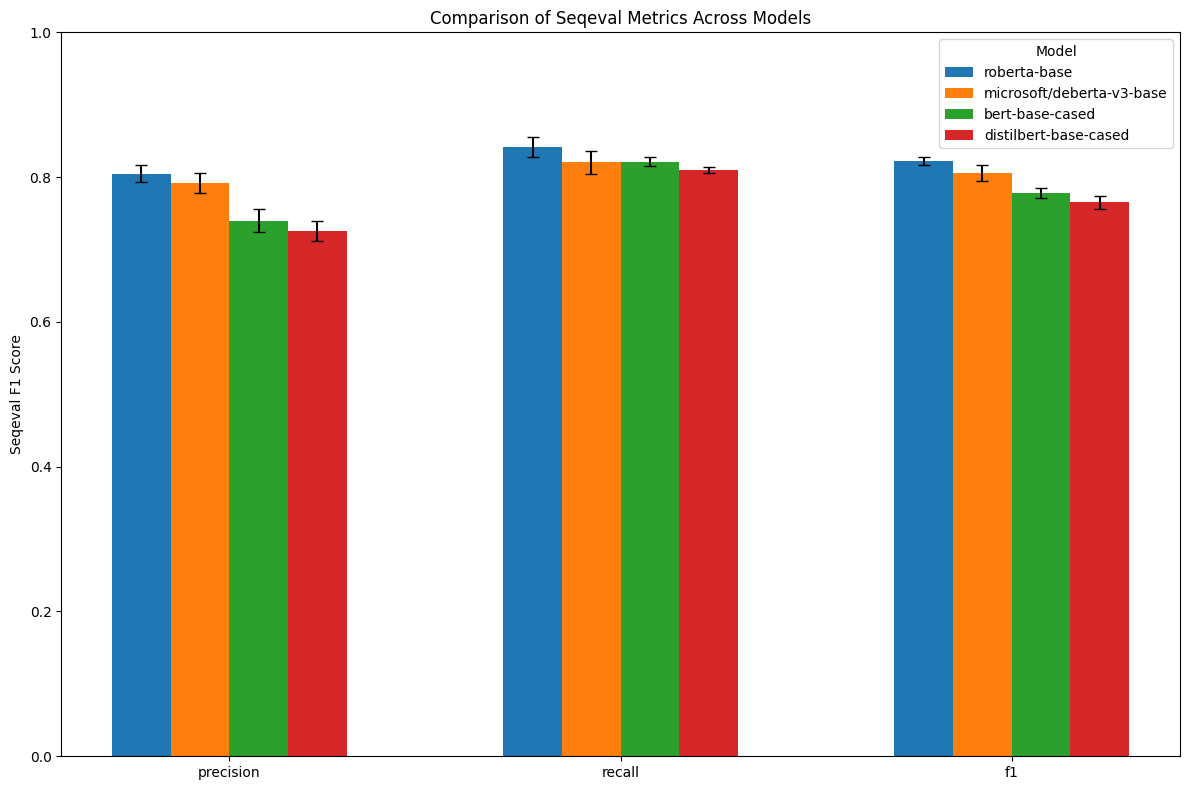

In [37]:
# define bert models to look at
models = list(bert_metrics.keys())
metrics = ['precision', 'recall', 'f1']
mean_values = np.array([[bert_metrics[m]['seqeval'][metric]["mean"] for metric in metrics] for m in models])
lower_values = np.array([[bert_metrics[m]['seqeval'][metric]["lower"] for metric in metrics] for m in models])
upper_values = np.array([[bert_metrics[m]['seqeval'][metric]["upper"] for metric in metrics] for m in models])
yerr = np.stack([
    mean_values - lower_values,
    upper_values - mean_values
])

# create the plot
x = np.arange(len(metrics))
width = 0.15
fig, ax = plt.subplots(figsize=(12, 8))
for i, model in enumerate(models):
    ax.bar(
        x + i * width, mean_values[i], width, yerr=yerr[:, i, :], capsize=4, label=model
    )
ax.set_xticks(x + width*(len(models)-1)/2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Seqeval F1 Score')
ax.set_ylim(0, 1)
ax.set_title('Comparison of Seqeval Metrics Across Models')
ax.legend(title="Model")
plt.tight_layout()
plt.show()

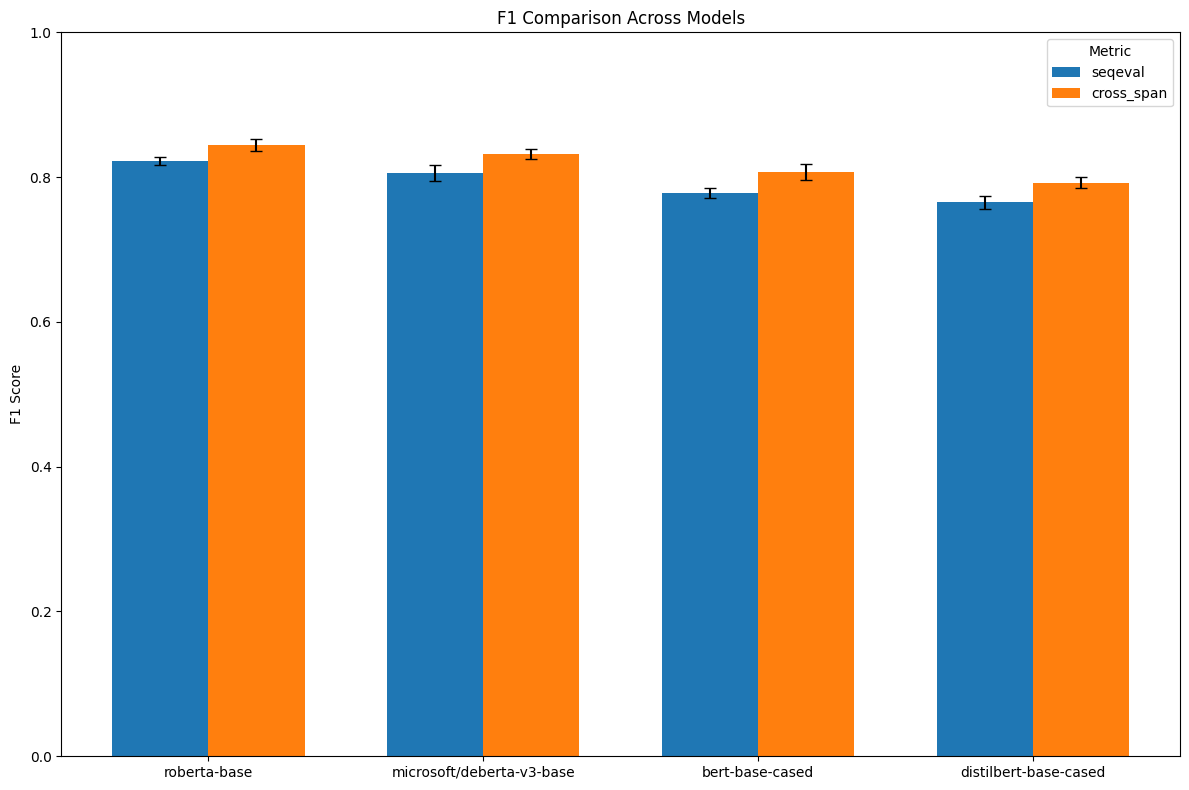

In [33]:
models = list(bert_metrics.keys())
metrics = ['seqeval', 'cross_span']

mean_values = np.array([[bert_metrics[m][metric]["f1"]["mean"] for metric in metrics] for m in models])
lower_values = np.array([[bert_metrics[m][metric]["f1"]["lower"] for metric in metrics] for m in models])
upper_values = np.array([[bert_metrics[m][metric]["f1"]["upper"] for metric in metrics] for m in models])

yerr = np.stack([
    mean_values - lower_values,
    upper_values - mean_values
])

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

for i, metric in enumerate(metrics):
    ax.bar(
        x + i * width,
        mean_values[:, i],
        width,
        yerr=yerr[:, :, i],
        capsize=4,
        label=metric
    )

ax.set_xticks(x + width * (len(metrics) - 1) / 2)
ax.set_xticklabels(models)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
ax.set_title("F1 Comparison Across Models")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

# Comparison of Generative Models

## Lineplot Showing Development over Few-Shot Examples

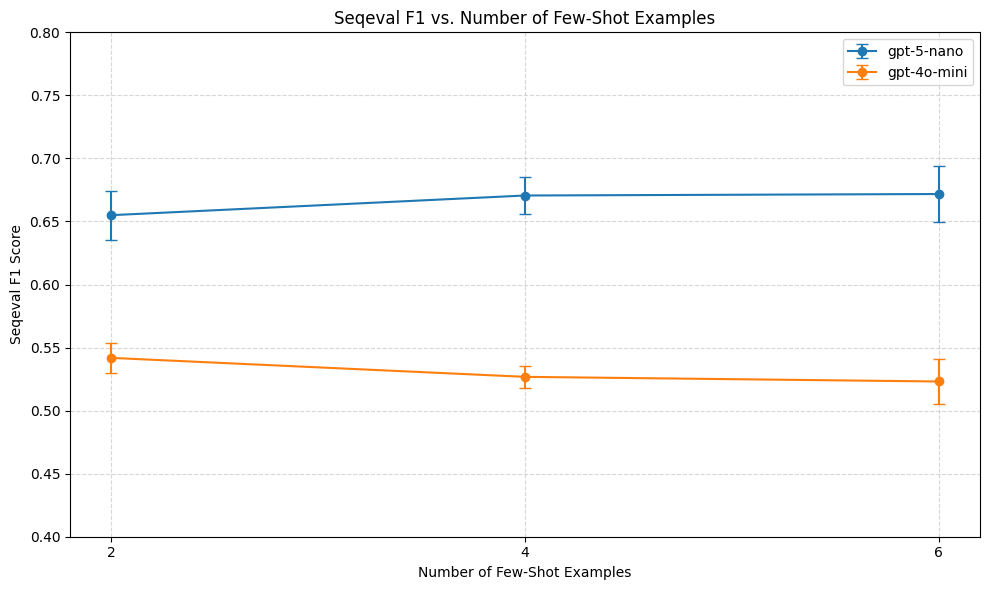

In [17]:
models = list(gpt_results.keys())

# extract and sort few-shot settings numerically
few_shot_keys = sorted(
    next(iter(gpt_results.values())).keys(),
    key=lambda x: int(x.split("_")[0])
)
few_shots = [int(k.split("_")[0]) for k in few_shot_keys]

means = {}
lower = {}
upper = {}
yerr = {}

for model in models:
    means[model] = [
        gpt_results[model][k]["seqeval"]["f1"]["mean"]
        for k in few_shot_keys
    ]
    lower[model] = [
        gpt_results[model][k]["seqeval"]["f1"]["lower"]
        for k in few_shot_keys
    ]
    upper[model] = [
        gpt_results[model][k]["seqeval"]["f1"]["upper"]
        for k in few_shot_keys
    ]
    yerr[model] = np.array([
        np.array(means[model]) - np.array(lower[model]),
        np.array(upper[model]) - np.array(means[model])
    ])

fig, ax = plt.subplots(figsize=(10, 6))

for model in models:
    ax.errorbar(
        few_shots,
        means[model],
        yerr=yerr[model],
        marker="o",
        linestyle="-",
        capsize=4,
        label=model
    )

ax.set_xticks(few_shots)
ax.set_xlabel("Number of Few-Shot Examples")
ax.set_ylabel("Seqeval F1 Score")
ax.set_ylim(0.4, 0.8)
ax.set_title("Seqeval F1 vs. Number of Few-Shot Examples")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()